# Wind Power Forecasting
_A graph machine learning project by group 25_

## Environment Setup

In [13]:
%pip install torch_geometric

Note: you may need to restart the kernel to use updated packages.


In [14]:
# Standard Libraries
import random
import time
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import math
from typing import Tuple, Callable, Sequence

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim as optim
from tqdm import tqdm

# PyTorch Geometric
from torch_geometric.nn.conv import GCNConv, TAGConv, GATConv
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeoDataLoader
from torch_geometric.utils import dense_to_sparse
from torch_geometric.utils import softmax

# Plotting
import matplotlib.pyplot as plt

print("All libraries imported successfully.")

All libraries imported successfully.


To ensure reproducible results:

In [15]:
def set_seed(seed):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        print(f"Seed set to: {seed}")
    else:
        print("No seed provided; using random initialization.")

set_seed(42)

Seed set to: 42


## Configuration

In [16]:
SEQ_LEN = 24 # (1 step = 10 min -> 24 steps = 4 hours)
HORIZONS = 6
BATCH_SIZE = 32
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 1e-3
EPOCHS = 10 # Increases likely boosts performance, but dramatically increases runtime (each of the 134 turbines trains for X epochs)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


## Dataset

In [17]:
df_sensor_data = pd.read_csv(
    "/kaggle/input/wind-farm-power-forecasting/85b5cb4eea5a4f259766f42a448e2c04a7499c43e1ae4cc28fbdee8e087e2385")
print("Sensor data loaded successfully.")

df_positions = pd.read_csv(
    "/kaggle/input/wind-farm-power-forecasting/e927ce742c884955bf2a667929d36b2ef41c572cd6e245fa86257ecc2f7be7bc")
print("Position data loaded successfully.")


Sensor data loaded successfully.
Position data loaded successfully.


In [18]:
def build_spatial_graph(positions: np.ndarray, sigma_s: float = 1000) -> np.ndarray:
    """Builds a spatial graph using a Gaussian kernel based on turbine positions.
    
    Args:
        positions (np.ndarray): Array of shape (num_turbines, 2) with (x, y) coordinates.
        sigma_s (float): Standard deviation for the Gaussian kernel.
    
    Returns:
        np.ndarray: Weighted adjacency matrix W of shape (num_turbines, num_turbines).
    """

    print("Building spatial graph...")

    dist = cdist(positions, positions)
    W = np.exp(-dist ** 2 / (2 * sigma_s ** 2))
    np.fill_diagonal(W, 0)

    print("Spatial graph built successfully.")
    
    return W

# Construct spatial graph
positions = df_positions[["x", "y"]].values
W = build_spatial_graph(positions)

# Compute graph Laplacian
D = np.diag(W.sum(axis=1))
L = D - W

Building spatial graph...
Spatial graph built successfully.


In [19]:
def build_knn_edges(W: np.ndarray, k: int = 5):
    """
    Builds edge_index and edge_weight tensors from adjacency matrix W using k-NN.
    
    Args:
        W (np.ndarray): Weighted adjacency matrix.
        k (int): Number of nearest neighbors to connect per node.
    
    Returns:
        edge_index (np.ndarray): Shape (2, num_edges)
        edge_weight (np.ndarray): Shape (num_edges,)
    """
    num_nodes = W.shape[0]
    edge_list = []
    weight_list = []

    for i in range(num_nodes):
        # Get indices of k largest weights (excluding self)
        neighbors = np.argsort(W[i])[-k:]
        for j in neighbors:
            if W[i, j] > 0:
                edge_list.append([i, j])
                weight_list.append(W[i, j])
    
    edge_index = np.array(edge_list).T  # shape (2, num_edges)
    edge_weight = np.array(weight_list)
    return edge_index, edge_weight

edge_index, edge_weight = build_knn_edges(W, k=5)
edge_index_tensor = torch.tensor(edge_index, dtype=torch.int, device=DEVICE)
edge_weight_tensor = torch.tensor(edge_weight, dtype=torch.float, device=DEVICE)
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)


edge_index shape: (2, 670)
edge_weight shape: (670,)


In [20]:
def harmonic_interpolation_one_timestep(values, L, W):
    observed_mask = ~np.isnan(values)
    unlabeled_mask = np.isnan(values)
    if unlabeled_mask.sum() == 0:
        return values
    labeled_idx = np.where(observed_mask)[0]
    unlabeled_idx = np.where(unlabeled_mask)[0]
    L_uu = L[np.ix_(unlabeled_idx, unlabeled_idx)]
    L_ul = L[np.ix_(unlabeled_idx, labeled_idx)]
    f_L = values[labeled_idx]
    f_U = -np.linalg.solve(L_uu, L_ul @ f_L)
    filled = np.copy(values)
    filled[unlabeled_idx] = f_U
    return filled

data = df_sensor_data.sort_values(["Day", "Tmstamp", "TurbID"])
turbine_ids = sorted(data["TurbID"].unique())
features = ["Wspd", "Wdir", "Etmp", "Itmp", "Ndir", "Pab1", "Pab2", "Pab3", "Prtv", "Patv"]
scaled_features = ["Wspd", "Etmp", "Itmp"]
filled_records = []
print("Starting harmonic interpolation for missing data...")
for (day, tstamp), group in data.groupby(["Day", "Tmstamp"]):
    group = group.set_index("TurbID").reindex(turbine_ids)
    filled_group = group.copy()
    for feat in features:
        vals = group[feat].to_numpy(dtype=float)
        filled_vals = harmonic_interpolation_one_timestep(vals, L, W)
        filled_group[feat] = filled_vals
    filled_records.append(filled_group.reset_index())
df_sensor_data_imputed = pd.concat(filled_records, ignore_index=True)
df_sensor_data_imputed['datetime'] = pd.to_datetime(
    df_sensor_data_imputed['Day'].astype(str) + ' ' + df_sensor_data_imputed['Tmstamp'],
    format='%j %H:%M')
print("Harmonic interpolation completed.")

scaler_X = StandardScaler()
df_sensor_data_imputed[scaled_features] = scaler_X.fit_transform(df_sensor_data_imputed[scaled_features])
df_sensor_data_imputed["Wdir"] = (
    (df_sensor_data_imputed["Wdir"] + 180) % 360 - 180
)

print(df_sensor_data_imputed)

Starting harmonic interpolation for missing data...
Harmonic interpolation completed.
         TurbID  Day Tmstamp      Wspd  Wdir      Etmp      Itmp    Ndir  \
0             1    1   00:00 -1.464384  0.00 -0.479711 -1.469544   -0.00   
1             2    1   00:00 -1.464384  0.00 -0.479711 -1.469544   -0.00   
2             3    1   00:00 -1.464384  0.00 -0.479711 -1.469544   -0.00   
3             4    1   00:00 -1.464384  0.00 -0.479711 -1.469544   -0.00   
4             5    1   00:00 -1.464384  0.00 -0.479711 -1.469544   -0.00   
...         ...  ...     ...       ...   ...       ...       ...     ...   
4727515     130  245   23:50  0.891893 -2.49 -0.485478 -1.039013  366.18   
4727516     131  245   23:50  1.100231 -0.89 -0.486773 -0.737209  186.90   
4727517     132  245   23:50  1.566792 -3.42 -0.504430 -0.870804  278.12   
4727518     133  245   23:50  0.777453 -5.55 -0.462054 -1.152054  231.58   
4727519     134  245   23:50  1.082625  0.52 -0.480417 -1.232103  216.51   

 

In [21]:
class WindDataset(Dataset):
    """Sequence dataset: returns (X_seq, y_next) where
       X_seq: (seq_len, N, F) and y_next: (N,) for the next timestep target."""
    def __init__(self, timesteps: torch.Tensor, targets: torch.Tensor, seq_len: int, horizons=12):
        assert timesteps.dim() == 3  # (T, N, F)
        assert targets.dim() == 2    # (T, N)
        self.timesteps = timesteps
        self.targets = targets
        self.seq_len = seq_len
        self.num_samples = max(0, timesteps.size(0) - seq_len- horizons + 1)
        self.horizons = horizons

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx: int):
        # X: seq_len timesteps starting at idx -> shape (seq_len, N, F)
        # y: target at idx + seq_len -> shape (N,)
        X = self.timesteps[idx: idx + self.seq_len]
        y = self.targets[idx + self.seq_len:idx + self.seq_len+self.horizons]
        return X, y

def create_dataset(df: pd.DataFrame, feature_columns: Sequence[str], target_column: str, seq_len: int, horizons: int) -> WindDataset:
    """Builds a WindDataset from grouped dataframe ordered by datetime and TurbID."""
    timesteps = []
    targets = []
    for t, group in df.groupby('datetime'):
        group = group.sort_values('TurbID')
        x = torch.tensor(group[feature_columns].values, dtype=torch.float)   # (N, F)
        y = torch.tensor(group[target_column].values, dtype=torch.float)     # (N,)
        timesteps.append(x)
        targets.append(y)
    if len(timesteps) == 0:
        raise ValueError("No timesteps found in dataframe passed to create_dataset().")
    timesteps_tensor = torch.stack(timesteps)  # (T, N, F)
    targets_tensor = torch.stack(targets)      # (T, N)
    return WindDataset(timesteps_tensor, targets_tensor, seq_len=seq_len, horizons=horizons)

In [22]:
unique_times = df_sensor_data_imputed['datetime'].sort_values().unique()

train_end = int(len(unique_times) * 0.7)
test_end = int(len(unique_times) * 0.85)

train_times = unique_times[:train_end]
test_times = unique_times[train_end:test_end]
val_times = unique_times[test_end:]

train_df = df_sensor_data_imputed[df_sensor_data_imputed['datetime'].isin(train_times)]
val_df = df_sensor_data_imputed[df_sensor_data_imputed['datetime'].isin(val_times)]
test_df = df_sensor_data_imputed[df_sensor_data_imputed['datetime'].isin(test_times)]

feature_cols = ['Wspd', 'Wdir', 'Etmp', 'Itmp', 'Ndir', 'Pab1', 'Pab2', 'Pab3', 'Prtv', 'Patv']
target_col = 'Patv'

# Create datasets and dataloaders (use configured BATCH_SIZE and sensible drop_last)
train_data = create_dataset(train_df, feature_cols, target_col, seq_len=SEQ_LEN, horizons=HORIZONS)
val_data   = create_dataset(val_df, feature_cols, target_col, seq_len=SEQ_LEN, horizons=HORIZONS)
test_data  = create_dataset(test_df, feature_cols, target_col, seq_len=SEQ_LEN, horizons=HORIZONS)

print(f"Datasets: train={len(train_data)} samples, val={len(val_data)} samples, test={len(test_data)} samples")

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

W_tensor = torch.tensor(W, dtype=torch.float, device=DEVICE)

Datasets: train=24667 samples, val=5263 samples, test=5263 samples


## ML Pipeline
Regularizer

In [23]:
def prepare_distance_tensors(df_positions, device):
    coords = df_positions.sort_values('TurbID')[[ 'x','y']].values.astype(np.float32)  # (N,2)
    N = coords.shape[0]
    coords_t = torch.tensor(coords, device=device)  # (N,2)
    # compute pairwise vectors r_j - r_i => shape (N,N,2)
    r_i = coords_t.unsqueeze(1)  # (N,1,2)
    r_j = coords_t.unsqueeze(0)  # (1,N,2)
    v = r_j - r_i                # (N,N,2)
    dist = torch.norm(v, dim=-1) # (N,N)
    # Avoid 0 on diagonal, because of inverse
    dist_mask = dist.clone()
    dist_mask[dist_mask == 0] = 1.0
    v_unit = v / dist_mask.unsqueeze(-1)   # (N,N,2)
    inv_d2 = torch.zeros_like(dist)
    inv_d2[dist > 0] = 1.0 / (dist[dist > 0] ** 2)
    return v_unit, inv_d2
device = DEVICE
v_unit_tensor, inv_d2_tensor = prepare_distance_tensors(df_positions, device)

In [24]:
def wake_regularizer_vectorized(pred_patv, wind_dir_deg, nacelle_dir_deg, wind_speed, v_unit, inv_d2, cone_half_angle=20.0):
    """
    pred_patv: (B, N) predicted power (torch tensor, device matches v_unit)
    wind_dir_deg, nacelle_dir_deg, wind_speed: (B, N) tensors (degrees for angles, speed units)
    v_unit: (N, N, 2) unit vectors from i->j (torch tensor on same device)
    inv_d2: (N, N) 1 / distance^2 tensor (same device)
    Returns: scalar tensor loss (averaged over batch)
    """
    B, N = pred_patv.shape
    device = pred_patv.device
    loss_wake = torch.zeros((), device=device)

    cos_limit = np.cos(np.deg2rad(cone_half_angle))

    # compute downwind vector for each turbine in batch (B, N, 2)
    # wind_from = (nacelle + wind_dir) % 360 -> downwind_dir = (wind_from + 180) % 360
    wind_from = (nacelle_dir_deg + wind_dir_deg) % 360.0
    downwind = (wind_from + 180.0) % 360.0
    # to radians
    rad = downwind * (torch.pi / 180.0)
    w_x = torch.cos(rad)
    w_y = torch.sin(rad)
    wvec = torch.stack([w_x, w_y], dim=-1)  # (B, N, 2)

    # compute by broadcasting
    # wvec.unsqueeze(2): (B, N, 1, 2) ; v_unit.unsqueeze(0): (1, N, N, 2)

    # The broadcasting happens according to PyTorch's rules:
    # 1. Starting from the rightmost dimension, tensors must either:
    #    - Have the same size in that dimension, or
    #    - One of them has size 1, or
    #    - One of them doesn't have the dimension
    # 2. When a size-1 dimension meets a larger size, it's repeated to match
    
    cos_angles = (wvec.unsqueeze(2) * v_unit.unsqueeze(0)).sum(-1)  # (B, N, N)

    # mask for cone
    cos_limit = torch.cos(torch.deg2rad(torch.tensor(cone_half_angle, device=device)))
    mask = (cos_angles > cos_limit).float()  # (B, N, N)

    # violation = relu(pred[j] - pred[i]) for each pair (i,j)
    # pred.unsqueeze(1): (B, 1, N) -> pred_j
    # pred.unsqueeze(2): (B, N, 1) -> pred_i
    pred_diff = pred_patv.unsqueeze(1) - pred_patv.unsqueeze(2)  # (B, N, N) where entry [b,i,j] = pred[b,j] - pred[b,i]
    violation = torch.relu(pred_diff)  # (B, N, N) -> only add term if it's positive

    # weight = inv_d2[i,j] * cos_angles * wind_speed[b, i] ** 3
    # ws3 = wind_speed.unsqueeze(2) ** 3  # (B, N, 1) -> broadcast to (B,N,N)
    weight = inv_d2.unsqueeze(0) * cos_angles  # (B, N, N)
    weighted_violation = violation * weight * mask
    loss = weighted_violation.sum() / max(1, B)
    return loss

This function defined the training loop that is used for all models.

In [25]:
def do_train(model : nn.Module, train_loader : DataLoader, val_loader : DataLoader,
             model_name: str, model_caller : Callable,
             use_physics_reg: bool = False, lambda_wake: float = 0.02) -> Tuple[list, list]:
    """Trains the given model and validates it, saving the best model based on validation loss.
    
    Args:
        model (nn.Module): The PyTorch model to train.
        train_loader (DataLoader): DataLoader for training data.
        val_loader (DataLoader): DataLoader for validation data.
        model_name (str): Name of the model (used for saving).
        model_caller (callable): Function to call the model's forward pass.
        use_physics_reg (bool): Whether to apply the physics wake regularizer.
        lambda_wake (float): Regularization strength.
    
    Returns:
        tuple: (train_losses, val_losses) lists containing loss values per epoch.
    """
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    epochs_no_improve = 0
    early_stop_patience = 5
    best_model_path = f"/kaggle/working/best_{model_name}.pth"

    # prepare physics tensors once if needed
    if use_physics_reg:
        v_unit_tensor, inv_d2_tensor = prepare_distance_tensors(df_positions, DEVICE)
        idx_wdir = feature_cols.index("Wdir")
        idx_nac  = feature_cols.index("Ndir")
        idx_wspd = feature_cols.index("Wspd")

    for epoch in range(EPOCHS):
        epoch_start = time.time()
        # --- TRAIN ---
        model.train()
        total_train_loss = 0

        train_iter = tqdm(enumerate(train_loader), total=len(train_loader),
                              desc=f"[{model_name}] Epoch {epoch+1}/{EPOCHS} (train)", unit="batch")

        for i, (X_batch, y_batch) in train_iter:
            optimizer.zero_grad()
            y_pred = model_caller(X_batch.to(DEVICE))
            loss = criterion(y_pred, y_batch.to(DEVICE))

            # ---------- physics wake regularizer ----------
            if use_physics_reg:
                B, T, N, F = X_batch.shape
                last_feats_scaled = X_batch[:, -1, :, :].to(DEVICE)
                eps = 1e-8

                # Build full-length scale/mean arrays aligned with feature_cols.
                # scaler_X was fit only on `scaled_features` (e.g. ['Wspd','Etmp','Itmp']),
                # so for features not in that list we keep scale=1 and mean=0 (no change).
                feat_count = len(feature_cols)
                scale_arr = np.ones(feat_count, dtype=float)
                mean_arr = np.zeros(feat_count, dtype=float)
                for j, feat in enumerate(feature_cols):
                    if feat in scaled_features:
                        idx = scaled_features.index(feat)
                        scale_arr[j] = scaler_X.scale_[idx]
                        mean_arr[j] = scaler_X.mean_[idx]

                scale = torch.tensor(scale_arr, dtype=torch.float32, device=DEVICE).view(1, 1, -1)
                mean_ = torch.tensor(mean_arr, dtype=torch.float32, device=DEVICE).view(1, 1, -1)

                # sanity check: ensure feature counts match
                assert F == feat_count, f"Feature dim mismatch: tensor F={F}, feature_cols length={feat_count}"

                last_feats_unscaled = (last_feats_scaled - mean_) / (scale + eps)

                wind_dir_batch   = last_feats_unscaled[:, :, idx_wdir]
                nacelle_dir_batch = last_feats_unscaled[:, :, idx_nac]
                wind_speed_batch  = last_feats_unscaled[:, :, idx_wspd]

                # handle multi-horizon outputs if present
                patv_pred = y_pred[:, -1, :] if y_pred.ndim == 3 else y_pred

                loss_reg = wake_regularizer_vectorized(
                    pred_patv=patv_pred,
                    wind_dir_deg=wind_dir_batch,
                    nacelle_dir_deg=nacelle_dir_batch,
                    wind_speed=wind_speed_batch,
                    v_unit=v_unit_tensor,
                    inv_d2=inv_d2_tensor,
                    cone_half_angle=35.0
                )
                loss = loss + lambda_wake * loss_reg
            # ------------------------------------------------

            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            train_iter.set_postfix(train_loss=f"{total_train_loss / (i+1):.4f}")

        avg_train_loss = total_train_loss / max(1, len(train_loader))
        train_losses.append(avg_train_loss)

        # --- VALIDATE ---
        model.eval()
        total_val_loss = 0.0

        val_iter = tqdm(val_loader, total=len(val_loader), 
                        desc=f"[{model_name}] Epoch {epoch+1}/{EPOCHS} (val)", unit="batch")

        with torch.no_grad():
            for X_batch, y_batch in val_iter:
                y_pred = model_caller(X_batch.to(DEVICE))
                loss = criterion(y_pred, y_batch.to(DEVICE))
                total_val_loss += loss.item()

                val_iter.set_postfix(val_loss=f"{total_val_loss / (len(val_iter) if len(val_iter)>0 else 1):.4f}")

        avg_val_loss = total_val_loss / max(1, len(val_loader))
        val_losses.append(avg_val_loss)

        # --- SAVE MODEL EACH EPOCH ---
        torch.save(model.state_dict(), f"/kaggle/working/{model_name}_epoch{epoch+1}.pth")

        # --- CHECK FOR BEST MODEL ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_model_path)
            improved_msg = " (new best)"
        else:
            epochs_no_improve += 1
            improved_msg = ""

        epoch_time = time.time() - epoch_start

        print(f"[{model_name}] Epoch {epoch+1}/{EPOCHS} finished in {epoch_time:.1f}s — "
                  f"train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}{improved_msg}\n")

        # --- EARLY STOPPING ---
        if epochs_no_improve >= early_stop_patience:
            print(f"[{model_name}] Early stopping triggered after {epoch+1} epochs.")
            break

    print(f"[{model_name}] Training complete. Best model saved at: {best_model_path}")

    return train_losses, val_losses

In [26]:
def plot_train_val_losses(train_losses, val_losses,
                         title="Training and Validation Loss",
                         xlabel="Epoch", ylabel="Loss",
                         save_path=None, dpi=150):
    """
    Plot training and validation loss curves on a single figure.

    Args:
        train_losses (list or array): per-epoch training losses
        val_losses   (list or array): per-epoch validation losses
        title (str): plot title
        xlabel, ylabel (str): axis labels
        save_path (str|None): if provided, save figure to this path
        dpi (int): saved figure resolution
    """
    import matplotlib.pyplot as plt
    epochs = list(range(1, max(len(train_losses), len(val_losses)) + 1))

    plt.figure(figsize=(8, 4))
    if len(train_losses) > 0:
        plt.plot(epochs[:len(train_losses)], train_losses, marker="o", label="Train")
    if len(val_losses) > 0:
        plt.plot(epochs[:len(val_losses)], val_losses, marker="s", label="Validation")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi)

    plt.show()

In [27]:
def evaluate_model(model, test_loader, edge_index_tensor, device, model_path):
    """
    Evaluate a model that outputs tuples of HORIZON numpy arrays per sample.
    Computes per-component and overall MAE + standard deviation.

    Args:
        model: torch.nn.Module — trained model to evaluate
        test_loader: DataLoader — test data loader
        edge_index_tensor: torch.Tensor — graph edge index for GAT input
        device: torch.device — e.g., torch.device("cuda" or "cpu")
        model_path: str — path to .pth file for model weights

    Returns:
        dict containing:
            - per_comp_mae
            - per_comp_std
            - overall_mae
            - overall_mae_std
            - mean_of_per_comp_std
    """
    # Load model
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()

    preds, trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch.to(device), edge_index_tensor)
            preds.extend(y_pred.cpu().numpy())
            trues.extend(y_batch.numpy())

    preds = np.array(preds)
    trues = np.array(trues)

    n_samples = len(preds)
    n_components = len(preds[0])

    # Collect per-component lists
    per_comp_preds = [[] for _ in range(n_components)]
    per_comp_trues = [[] for _ in range(n_components)]

    for p, t in zip(preds, trues):
        for i in range(n_components):
            per_comp_preds[i].append(np.asarray(p[i]))
            per_comp_trues[i].append(np.asarray(t[i]))

    # Compute mean across samples for each component
    per_comp_mae, per_comp_std = [], []
    for i in range(n_components):
        stacked_p = np.stack(per_comp_preds[i], axis=0)
        stacked_t = np.stack(per_comp_trues[i], axis=0)

        mean_pred_i = stacked_p.mean(axis=0)
        mean_true_i = stacked_t.mean(axis=0)

        abs_err_i = np.abs(mean_pred_i - mean_true_i)
        mae_i = abs_err_i.mean()
        std_i = abs_err_i.std()

        per_comp_mae.append(mae_i)
        per_comp_std.append(std_i)

    per_comp_mae = np.array(per_comp_mae)
    per_comp_std = np.array(per_comp_std)

    # Aggregate across components
    overall_mae = per_comp_mae.mean()
    overall_mae_std = per_comp_mae.std()
    mean_of_per_comp_std = per_comp_std.mean()

    # Print results
    print("=== Evaluation Results ===")
    print(f"Per-component MAEs: {per_comp_mae}")
    print(f"Per-component STD of abs-errors: {per_comp_std}")
    print(f"Overall MAE (mean of 6 component MAEs): {overall_mae:.6f}")
    print(f"STD of the 6 component MAEs: {overall_mae_std:.6f}")
    print(f"Mean(per-component STD of abs-errors): {mean_of_per_comp_std:.6f}")
    print("===========================")

In [28]:
def compute_mae_std(preds, trues):
    """
    Compute proper MAE and STD given preds and trues.

    Args:
        preds: list/array of model predictions
        trues: list/array of ground truths
    """
    n_components = len(preds[0])
    per_comp_preds = [[] for _ in range(n_components)]
    per_comp_trues = [[] for _ in range(n_components)]

    for p, t in zip(preds, trues):
        for i in range(n_components):
            per_comp_preds[i].append(np.asarray(p[i]))
            per_comp_trues[i].append(np.asarray(t[i]))

    per_comp_mae, per_comp_std = [], []
    for i in range(n_components):
        stacked_p = np.stack(per_comp_preds[i], axis=0)
        stacked_t = np.stack(per_comp_trues[i], axis=0)

        mean_pred_i = stacked_p.mean(axis=0)
        mean_true_i = stacked_t.mean(axis=0)

        abs_err_i = np.abs(mean_pred_i - mean_true_i)
        per_comp_mae.append(abs_err_i.mean())
        per_comp_std.append(abs_err_i.std())

    per_comp_mae = np.array(per_comp_mae)
    per_comp_std = np.array(per_comp_std)

    overall_mae = per_comp_mae.mean()
    overall_std = per_comp_mae.std()

    print("=== Statistics (Tuple Outputs) ===")
    print(f"Per-component MAEs: {per_comp_mae}")
    print(f"Per-component STDs: {per_comp_std}")
    print(f"Overall MAE: {overall_mae:.6f}")
    print(f"STD of component MAEs: {overall_std:.6f}")
    print("==================================")

## LSTM Baseline

In [29]:
class LSTMForecaster(nn.Module):
    """LSTM-based forecaster for wind power prediction.
    
    Args:
        input_size (int): Number of input features.
        hidden_dim (int): Dimension of LSTM hidden states.
        num_layers (int): Number of LSTM layers.
    """
    def __init__(self, input_size, hidden_dim, num_layers, horizons=6):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, horizons)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :]) # Use the last time step's output
        return out

In [30]:
# instantiate LSTM baseline model
model = LSTMForecaster(input_size=len(feature_cols), hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, horizons=HORIZONS)
model.to(DEVICE)

LSTMForecaster(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)

In [ ]:
def lstm_model_caller(X_batch):
    """Adapts input shape for LSTM model.
    
    Args:
        X_batch (torch.Tensor): Input tensor of shape (B, S, N, F)
                                     where B=batch size, S=sequence length, N=number of turbines, F=number of features.

    Returns:
        torch.Tensor: Output tensor of shape (B, N).
    """
    # X_batch comes from do_train as X_batch.to(DEVICE)
    B, S, N, F = X_batch.shape
    X_flat = X_batch.permute(0, 2, 1, 3).contiguous().view(B * N, S, F)  # (B*N, S, F)
    out = model(X_flat)           # (B*N, 1)
    out = out.view(B, N, HORIZONS)      # [B, N, HORIZONS]
    out = out.permute(0, 2, 1)# (B, N) to match y_batch shape used in do_train
    return out

# Train LSTM baseline
lstm_train_losses, lstm_val_losses = do_train(model, train_loader, val_loader, "lstm_baseline", model_caller=lstm_model_caller, use_physics_reg=False)


In [ ]:
plot_train_val_losses(lstm_train_losses, lstm_val_losses, title="LSTM Baseline Training and Validation Loss")

In [ ]:
model.load_state_dict(torch.load("/kaggle/working/best_lstm_baseline.pth", map_location=torch.device(DEVICE)))
model.to(DEVICE)
model.eval()

preds, trues = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # shapes: y_pred -> (B, N) on DEVICE, y_batch -> (B, N) on CPU
        y_pred = lstm_model_caller(X_batch.to(DEVICE))
        preds.append(y_pred.cpu().numpy())
        trues.append(y_batch.numpy())

if not preds:
    print("No test samples found.")
else:
    preds = np.concatenate(preds, axis=0)  # (num_batches*B, N)
    trues = np.concatenate(trues, axis=0)
    mae = np.mean(np.abs(preds - trues))
    std = np.std(np.abs(preds-trues)) / HORIZONS
    print("Test MAE:", mae)
    print("Test STD:", std)

In [ ]:
print(np.mean(np.abs(preds - trues)))

## LSTM + GCN Baseline

In [31]:
edge_index, edge_weight = dense_to_sparse(W_tensor)

def make_batched_edges(edge_index: torch.Tensor, edge_weight: torch.Tensor, N: int, num_graphs: int, device: torch.device):
    """
    Create batched edge_index and edge_weight for `num_graphs` identical graphs
    (used when we flatten B*T graphs into a single big graph for conv).
    """
    ei = edge_index.long().to(device)
    ew = edge_weight.to(device).float()

    offsets = (torch.arange(num_graphs, device=device, dtype=ei.dtype) * N).unsqueeze(1)  # (G,1)
    rows = ei[0].unsqueeze(0) + offsets  # (G,E)
    cols = ei[1].unsqueeze(0) + offsets  # (G,E)

    edge_index_batched = torch.cat([rows, cols], dim=0).reshape(2, -1).long()  # (2, G*E)
    edge_weight_batched = ew.unsqueeze(0).repeat(num_graphs, 1).reshape(-1)   # (G*E,)
    return edge_index_batched, edge_weight_batched

In [ ]:
class LSTMGCNForecaster(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, horizons=6):
        super().__init__()
        self.gnn = nn.ModuleList()
        self.gnn.append(TAGConv(input_size, 50, K=2))
        # self.gnn.append(TAGConv(50, 50, K=2))
        self.gnn.append(TAGConv(50, 50, K=2))
        # for i in range(2):
            # self.gnn.append(GCNConv(in_channels=input_size, out_channels=input_size))
        self.lstm = nn.LSTM(50, hidden_dim, num_layers, batch_first=True)
        # self.gnn = GCN(in_channels=input_size, hidden_channels=input_size, num_layers=2)
        self.fc = nn.Linear(hidden_dim, horizons)
        self.horizons = horizons

    def forward(self, x, edge_index_batched, edge_weight_batched):
        B, T, N, F = x.shape
        xt = x.reshape(B * T * N, F)
        for i, conv in enumerate(self.gnn):
            xt = conv(x=xt, edge_index=edge_index_batched, edge_weight=edge_weight_batched)
            xt = torch.relu(xt)
        y = xt.reshape(B, T, N, 50)
        y = y.permute(0, 2, 1, 3).reshape(B * N, T, 50)
        out, _ = self.lstm(y)
        out = self.fc(out[:, -1, :]) # Use the last time step's
        out = out.squeeze(-1).reshape(B, N, self.horizons)
        out = out.permute(0,2,1)
        return out

In [ ]:
model = LSTMGCNForecaster(input_size=len(features), hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, horizons=HORIZONS)
model.to(DEVICE)

In [ ]:
lstm_gcn_train_losses, lstm_gcn_val_losses = do_train(
    model,
    train_loader,
    val_loader,
    "lstm_gnn",
    model_caller=lambda xb: model(
        xb.to(DEVICE),
        *make_batched_edges(
            edge_index=edge_index,
            edge_weight=edge_weight,
            N=W.shape[0],
            num_graphs=(xb.size(0) * xb.size(1)),
            device=DEVICE,
        )
    ),
    use_physics_reg=False
)

In [ ]:
plot_train_val_losses(lstm_gcn_train_losses, lstm_gcn_val_losses, title="LSTM + GCN Training and Validation Loss")

In [ ]:
# Test cell for LSTM + GCN (build batched edges per test batch to avoid OOB)
model.load_state_dict(torch.load("/kaggle/working/best_lstm_gnn.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()

preds, trues = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        B, S, N, F = X_batch.shape
        # build batched adjacency for this batch (B * S graphs)
        edge_index_batched, edge_weight_batched = make_batched_edges(
            edge_index=edge_index,
            edge_weight=edge_weight,
            N=W.shape[0],
            num_graphs=(B * S),
            device=DEVICE,
        )
        y_pred = model(X_batch.to(DEVICE), edge_index_batched, edge_weight_batched)
        preds.append(y_pred.cpu().numpy())
        trues.append(y_batch.numpy())

if not preds:
    print("No test samples found.")
else:
    preds = np.concatenate(preds, axis=0)  # (num_batches * batch_size, N)
    trues = np.concatenate(trues, axis=0)
    mae = np.mean(np.abs(preds - trues))
    std = np.std((np.abs(preds - trues)) / HORIZONS)
    print("LSTM+GCN Test MAE:", mae)
    print("LSTM+GCN Test STD:", std)

## LSTM + GCN + Edge Attention

In [ ]:
class BatchedDynamicEdgeAttentionKNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, k=5, num_heads=4):
        super().__init__()
        self.Wq = nn.Linear(in_dim, hidden_dim * num_heads)
        self.Wk = nn.Linear(in_dim, hidden_dim * num_heads)
        # self.mha = nn.MultiheadAttention(embed_dim=in_dim,
                                         # num_heads=num_heads,
                                         # batch_first=True)
        self.num_heads = num_heads
        self.scale = math.sqrt(hidden_dim)
        self.hidden_dim = hidden_dim
        self.beta = None
        self.k = k

    def forward(self, x, W):
        """
        x: [B*T, N, F]
        W: [N, N] or [B, N, N]
        Returns:
            edge_index: [2, E] global edge index
            edge_weight: [E]
        """
        B, N, F = x.shape

        if self.beta is None or self.beta.shape[0] != N:
            self.beta = nn.Parameter(torch.ones(N, device=x.device))
            
        Q = self.Wq(x)  # [B, N, H]
        K = self.Wk(x)  # [B, N, H]

        # _, attn = self.mha(x,x,x)

        Q = Q.view(B, N, self.num_heads, self.hidden_dim)
        K = K.view(B, N, self.num_heads, self.hidden_dim)
        Q = Q.permute(0, 2, 1, 3)  # [B, num_heads, N, hidden_dim]
        K = K.permute(0, 2, 1, 3) 
        attn = torch.matmul(Q, K.transpose(-1, -2)) / self.scale  # [B, N, num_heads, N]
        attn = attn - attn.max(dim=-1, keepdim=True).values
        attn = torch.clamp(attn, -30, 30)
        attn = torch.softmax(attn, dim=-1)
        attn = attn.mean(dim=1)  

        # incorporate static adjacency
        if len(W.shape) == 2:
            Wb = W.unsqueeze(0).expand(B, -1, -1)
        else:
            Wb = W
        beta = torch.clamp(self.beta, 0, 5) 
        attn = attn * (1.0 + self.beta.view(1, -1, 1) * Wb)

        # --- top-k per row ---
        topk_val, topk_idx = torch.topk(attn, self.k, dim=-1)  # [B, N, k]

        topk_val = topk_val / (topk_val.sum(dim=-1, keepdim=True) + 1e-8)
        
        # row indices
        row_idx = torch.arange(N, device=x.device).view(1, N, 1).expand(B, N, self.k)
        batch_offset = (torch.arange(B, device=x.device) * N).view(B, 1, 1)
        
        row_idx_flat = (row_idx + batch_offset).reshape(-1)       # [B*T * N * k]
        col_idx_flat = (topk_idx + batch_offset).reshape(-1)      # [B*T * N * k]
        
        edge_index = torch.stack([row_idx_flat, col_idx_flat], dim=0)
        edge_weight = topk_val.reshape(-1)
        return edge_index, edge_weight

class AttentiveDenseGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, use_relu=True):
        super().__init__()
        self.attn = BatchedDynamicEdgeAttentionKNN(in_dim, hidden_dim, k=3)
        self.conv = TAGConv(in_dim, hidden_dim, K=2)
        self.conv2 = TAGConv(hidden_dim, out_dim, K=2)
        self.use_relu = use_relu

    def forward(self, x, W):
        # x: [B*T, N, F]
        # W: [N,N] or [B,N,N]
        BT, N, F = x.shape
        edge_index, edge_weight = self.attn(x, W)
        x_flat = x.reshape(BT * N, F)
        h = self.conv(x_flat, edge_index, edge_weight)  # [BT*N, out_dim]
        if self.use_relu:
            h = torch.relu(h)
        h = self.conv2(h, edge_index, edge_weight)  # [BT*N, out_dim]
        if self.use_relu:
            h = torch.relu(h)
        return h                               # [B, N, out_dim]

# 1) Spatial-first: per-timestep GCN -> LSTM across time for each node
class SpatialFirst_GCN_then_LSTM(nn.Module):
    def __init__(self, node_in_dim=10, attn_hidden=64, gcn_out=64,
                 lstm_hidden=128, lstm_layers=1, #lstm_bidirectional=False,
                 final_out_dim=1, horizons = 6):
        super().__init__()
        self.gcn = AttentiveDenseGCN(node_in_dim, attn_hidden, gcn_out)
        self.lstm_hidden = lstm_hidden
        self.lstm = nn.LSTM(input_size=gcn_out,
                            hidden_size=lstm_hidden,
                            num_layers=lstm_layers,
                            batch_first=True)
                            # bidirectional=lstm_bidirectional)
        # dir_mul = 2 if lstm_bidirectional else 1
        # self.final = nn.Linear(lstm_hidden * dir_mul, final_out_dim)
        self.final = nn.Linear(lstm_hidden, final_out_dim*horizons)
        self.horizons = horizons

    def forward(self, x, W):
        # x: [B, T, N, F]
        B, T, N, F = x.shape
        # Apply GCN per timestep (vectorized loop over T)
        gcn_outs = x.reshape(B * T, N, F)
        gcn_outs = self.gcn(gcn_outs, W)        # [B * T, N, gcn_out]
        gcn_seq = gcn_outs.reshape(B, T, N, -1)   # [B, T, N, gcn_out]
        # Prepare for LSTM: we want an LSTM per node across time.
        # reshape to (B*N, T, gcn_out)
        gcn_seq = gcn_seq.permute(0, 2, 1, 3).contiguous()  # [B, N, T, gcn_out]
        gcn_seq = gcn_seq.view(B * N, T, -1)                # [B*N, T, gcn_out]
        # LSTM across time for each (batch,node)
        lstm_out, (h_n, c_n) = self.lstm(gcn_seq)           # lstm_out: [B*N, T, H]
        # choose last timestep output (or h_n)
        last = lstm_out[:, -1, :]                          # [B*N, lstm_hidden * dir]
        last = last.view(B, N, -1)                         # [B, N, lstm_hidden*dir]
        out = self.final(last).squeeze(-1).reshape(B, N, self.horizons)          # [B, N, final_out_dim]
        out = out.permute(0, 2, 1)
        return out

In [ ]:
model = SpatialFirst_GCN_then_LSTM(node_in_dim=len(features))
model.to(DEVICE)

In [ ]:
lstm_gcn_attn_train_losses, lstm_gcn_attn_val_losses = do_train(model, train_loader, val_loader, "lstm_gnn_attention", model_caller=lambda xb: model(xb, W_tensor), use_physics_reg=True)

In [ ]:
plot_train_val_losses(lstm_gcn_attn_train_losses, lstm_gcn_attn_val_losses, title="LSTM + GCN + Attention Training and Validation Loss")

In [ ]:
model.load_state_dict(torch.load("/kaggle/working/best_lstm_gnn_attention.pth", map_location=torch.device(DEVICE)))
model.to(DEVICE)
model.eval()
preds, trues = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch.to(DEVICE), W_tensor)
        preds.extend(y_pred.cpu().numpy())
        trues.extend(y_batch.numpy())

preds = np.array(preds)
trues = np.array(trues)

mae = np.mean(abs(preds - trues))
print("Test MAE:", mae)

## GAT + LSTM on k-nn distance matrix

In [47]:
class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4, use_relu=True):
        super().__init__()
        self.gat = GATConv(in_dim, out_dim, heads=heads, concat=False, dropout=0.1)
        self.use_relu = use_relu

    def forward(self, x, edge_index):
        # x: [B*T, N, F]
        BT, N, F = x.shape
        x_flat = x.reshape(BT * N, F)
        h = self.gat(x_flat, edge_index)
        if self.use_relu:
            h = torch.relu(h)
        return h  # [BT*N, out_dim]


class GAT_with_LSTM(nn.Module):
    """
    Spatial-first model: per-timestep GAT -> LSTM across time for each node.
    """
    def __init__(self, node_in_dim=10, gat_out=64,
                 lstm_hidden=128, lstm_layers=1, final_out_dim=1,
                 horizons=6, k=8):
        super().__init__()
        self.k = k
        self.gat = GATLayer(node_in_dim, gat_out, heads=4)
        self.lstm_hidden = lstm_hidden
        self.lstm = nn.LSTM(
            input_size=gat_out,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True
        )
        self.final = nn.Linear(lstm_hidden, final_out_dim * horizons)
        self.horizons = horizons

    def forward(self, x, edge_index):
        """
        x: [B, T, N, F]
        W: [N, N] adjacency or spatial similarity matrix
        """
        B, T, N, F = x.shape

        # --- Spatial (GAT) per timestep ---
        gcn_outs = x.reshape(B * T, N, F)
        gcn_outs = self.gat(gcn_outs, edge_index)        # [B*T*N, gat_out]
        gcn_seq = gcn_outs.view(B, T, N, -1)             # [B, T, N, gat_out]

        # --- Temporal (LSTM) per node ---
        gcn_seq = gcn_seq.permute(0, 2, 1, 3).contiguous()  # [B, N, T, gat_out]
        gcn_seq = gcn_seq.view(B * N, T, -1)
        lstm_out, _ = self.lstm(gcn_seq)
        last = lstm_out[:, -1, :]
        last = last.view(B, N, -1)
        out = self.final(last).reshape(B, N, self.horizons)
        out = out.permute(0, 2, 1)  # [B, horizons, N]
        return out


In [48]:
model = GAT_with_LSTM(node_in_dim=len(features), gat_out=16)
model.to(DEVICE)

GAT_with_LSTM(
  (gat): GATLayer(
    (gat): GATConv(10, 16, heads=4)
  )
  (lstm): LSTM(16, 128, batch_first=True)
  (final): Linear(in_features=128, out_features=6, bias=True)
)

In [34]:
lstm_gat_train_losses, lstm_gat_val_losses = do_train(model, train_loader, val_loader, "lstm_gat", model_caller=lambda xb: model(xb, 
        make_batched_edges(
            edge_index=edge_index_tensor,
            edge_weight=edge_weight_tensor,
            N=W.shape[0],
            num_graphs=xb.size(0) * xb.size(1),
            device=DEVICE,
        )[0]), use_physics_reg=True)

[lstm_gat] Epoch 1/10 (val): 100%|██████████| 165/165 [00:05<00:00, 31.67batch/s, val_loss=205.8580]


[lstm_gat] Epoch 1/10 finished in 59.6s — train_loss=332.5370, val_loss=205.8580 (new best)



[lstm_gat] Epoch 2/10 (val): 100%|██████████| 165/165 [00:05<00:00, 31.05batch/s, val_loss=175.2556]


[lstm_gat] Epoch 2/10 finished in 58.1s — train_loss=290.8370, val_loss=175.2556 (new best)



[lstm_gat] Epoch 3/10 (val): 100%|██████████| 165/165 [00:05<00:00, 31.17batch/s, val_loss=153.2298]


...

[lstm_gat] Epoch 8/10 finished in 58.9s — train_loss=174.5649, val_loss=95.7264 (new best)



[lstm_gat] Epoch 9/10 (val): 100%|██████████| 165/165 [00:05<00:00, 31.55batch/s, val_loss=90.2889]


[lstm_gat] Epoch 9/10 finished in 58.7s — train_loss=164.3271, val_loss=90.2889 (new best)



[lstm_gat] Epoch 10/10 (val): 100%|██████████| 165/165 [00:05<00:00, 31.47batch/s, val_loss=86.7307]

[lstm_gat] Epoch 10/10 finished in 58.7s — train_loss=159.8697, val_loss=86.7307 (new best)

[lstm_gat] Training complete. Best model saved at: /kaggle/working/best_lstm_gat.pth


torch.Size([1, 24, 134, 10])


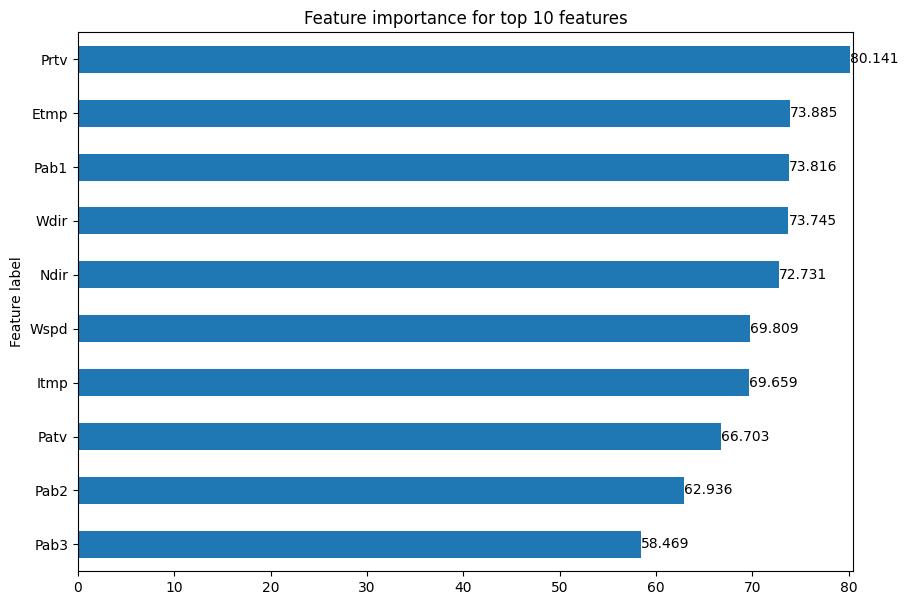

tensor([ 2, 23, 24,  1, 22]) tensor([0.6897, 0.6257, 0.6249, 0.5262, 0.4979]) tensor([0.2198, 0.2062, 0.2060, 0.1866, 0.1814])


In [49]:
# DEVICE = torch.device("cpu") #"cuda"

from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer
from torch_geometric.explain.algorithm import AttentionExplainer

class HorizonHead(nn.Module):
    def __init__(self, base, horizon_idx, N=None):
        super().__init__()
        self.base = base
        self.h = horizon_idx
        self.N = N
        
    def forward(self, x_flat, edge_index):
        # x_flat: [BT*N, F]
        BTN, F = x_flat.shape
        N = self.N
        BT = BTN // N
        x = x_flat.view(1, BT, N, F)
        # base returns [B, H, N]; keep node-wise scores [N]
        y = self.base(x, edge_index)[:, self.h, :]  # [B, N]
        return y.reshape(-1)  # assume B=1 -> [N]

model.load_state_dict(torch.load("/kaggle/working/best_lstm_gat.pth", map_location=torch.device(DEVICE)))
model.to(DEVICE)
model.eval()
# with torch.no_grad():
for X_batch, y_batch in test_loader:
    # pick sample b and target time index t_target (inclusive)
    b = 0
    x_bt = X_batch.to(DEVICE)[b:b+1, :, :, :]   # [1, 24, N, F]
    print(x_bt.shape)
    B, T, N, F = x_bt.shape
    # wrap and explainer as before
    wrapped = HorizonHead(model, horizon_idx=0, N=N).eval().to(DEVICE)
    explainer = Explainer(
        model=wrapped,
        algorithm=GNNExplainer(epochs=200),#AttentionExplainer(reduce="mean"),
        explanation_type="model",
        edge_mask_type="object",
        # node_mask_type=None
        node_mask_type="attributes",   # feature attributions
        model_config=dict(mode="regression", task_level="node", return_type="raw"),
    )
    BT = B * T
    # explain node u in the final time slice
    u = 0
    x_flat = x_bt.reshape(BT * N, F)

    edge_index_bt = make_batched_edges(
        edge_index=edge_index_tensor,
        edge_weight=edge_weight_tensor,
        N=N,
        num_graphs=BT,
        device=DEVICE,
    )[0]
    
    explanation = explainer(x=x_flat, edge_index=edge_index_bt.to(DEVICE), index=u)
    edge_mask = explanation.edge_mask
    ei = explanation.edge_index
    explanation.visualize_feature_importance(top_k=10, feat_labels=feature_cols)
    explanation.visualize_graph('graph.gv.pdf')
    # ei: [2, E], edge_mask: [E]
    u = 0
    sel_in = (ei[1] == u).to(DEVICE)                     # edges j -> u
    mask_in = edge_mask[sel_in]
    src_in  = ei[0, sel_in]
    if mask_in.numel() == 0:
        print("No inbound edges to u")
    else:
        vals, idx = torch.topk(mask_in, k=5)
        top_neighbors = src_in[idx]           # node ids of most impactful neighbors
        top_scores    = vals                  # their importance scores
        # Optional: normalize to a distribution over neighbors
        top_probs = torch.softmax(vals, dim=0)
        print(top_neighbors, top_scores, top_probs)
    break

In [ ]:
plot_train_val_losses(lstm_gat_train_losses, lstm_gat_val_losses, title="LSTM + GAT Training and Validation Loss")

In [ ]:
evaluate_model(model, test_loader, edge_index_tensor, DEVICE, "/kaggle/working/best_lstm_gat.pth")

## GAT + TAG + LSTM

In [ ]:
class GAT_TAG_Layer(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=4, use_relu=True, K=2):
        super().__init__()
        self.gat = GATConv(in_dim, hidden_dim, heads=heads, concat=False, dropout=0.1)
        self.tag = TAGConv(hidden_dim, out_dim, K=K)
        self.use_relu = use_relu

    def forward(self, x, edge_index):
        # x: [B*T, N, F]
        BT, N, F = x.shape
        x_flat = x.reshape(BT * N, F)
        h, (new_edge_index, edge_weight) = self.gat(x_flat, edge_index, return_attention_weights=True)
        edge_weight = edge_weight.mean(dim=-1)
        edge_weight = softmax(edge_weight, index=new_edge_index[0], num_nodes=BT*N)
        if self.use_relu:
            h = torch.relu(h)
        h = self.tag(h, new_edge_index, edge_weight=edge_weight)
        if self.use_relu:
            h = torch.relu(h)
        return h  # [BT*N, out_dim]


class GAT_TAG_with_LSTM(nn.Module):
    """
    Spatial-first model: per-timestep GAT -> LSTM across time for each node.
    """
    def __init__(self, node_in_dim=10, gat_hidden=64, gat_out=64,
                 lstm_hidden=128, lstm_layers=1, final_out_dim=1,
                 horizons=6, k=8):
        super().__init__()
        self.k = k
        self.gat = GAT_TAG_Layer(node_in_dim, gat_hidden, gat_out, heads=4)
        self.lstm_hidden = lstm_hidden
        self.lstm = nn.LSTM(
            input_size=gat_out,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True
        )
        self.final = nn.Linear(lstm_hidden, final_out_dim * horizons)
        self.horizons = horizons

    def forward(self, x, edge_index):
        """
        x: [B, T, N, F]
        W: [N, N] adjacency or spatial similarity matrix
        """
        B, T, N, F = x.shape

        # --- Spatial (GAT) per timestep ---
        gcn_outs = x.reshape(B * T, N, F)
        gcn_outs = self.gat(gcn_outs, edge_index)        # [B*T*N, gat_out]
        gcn_seq = gcn_outs.view(B, T, N, -1)             # [B, T, N, gat_out]

        # --- Temporal (LSTM) per node ---
        gcn_seq = gcn_seq.permute(0, 2, 1, 3).contiguous()  # [B, N, T, gat_out]
        gcn_seq = gcn_seq.view(B * N, T, -1)
        lstm_out, _ = self.lstm(gcn_seq)
        last = lstm_out[:, -1, :]
        last = last.view(B, N, -1)
        out = self.final(last).reshape(B, N, self.horizons)
        out = out.permute(0, 2, 1)  # [B, horizons, N]
        return out


In [ ]:
model = GAT_TAG_with_LSTM(node_in_dim=len(features), gat_hidden=16, gat_out=16)
model.to(DEVICE)

In [ ]:
lstm_gat_tag_train_losses, lstm_gat_tag_val_losses = do_train(model, train_loader, val_loader, "lstm_gat_tag", model_caller=lambda xb: model(xb, edge_index_tensor), use_physics_reg=True)

In [ ]:
evaluate_model(model, test_loader, edge_index_tensor, DEVICE, "/kaggle/working/best_lstm_gat_tag.pth")

In [ ]:
print(preds[0])

## Physical Regularizer

In [ ]:
def prepare_distance_tensors(df_positions, device):
    coords = df_positions.sort_values('TurbID')[[ 'x','y']].values.astype(np.float32)  # (N,2)
    N = coords.shape[0]
    coords_t = torch.tensor(coords, device=device)  # (N,2)
    # compute pairwise vectors r_j - r_i => shape (N,N,2)
    r_i = coords_t.unsqueeze(1)  # (N,1,2)
    r_j = coords_t.unsqueeze(0)  # (1,N,2)
    v = r_j - r_i                # (N,N,2)
    dist = torch.norm(v, dim=-1) # (N,N)
    # Avoid 0 on diagonal, because of inverse
    dist_mask = dist.clone()
    dist_mask[dist_mask == 0] = 1.0
    v_unit = v / dist_mask.unsqueeze(-1)   # (N,N,2)
    inv_d2 = torch.zeros_like(dist)
    inv_d2[dist > 0] = 1.0 / (dist[dist > 0] ** 2)
    return v_unit, inv_d2
device = DEVICE
v_unit_tensor, inv_d2_tensor = prepare_distance_tensors(df_positions, device)

In [ ]:
def wake_regularizer_vectorized(pred_patv, wind_dir_deg, nacelle_dir_deg, wind_speed, v_unit, inv_d2, cone_half_angle=45.0):
    """
    pred_patv: (B, N) predicted power (torch tensor, device matches v_unit)
    wind_dir_deg, nacelle_dir_deg, wind_speed: (B, N) tensors (degrees for angles, speed units)
    v_unit: (N, N, 2) unit vectors from i->j (torch tensor on same device)
    inv_d2: (N, N) 1 / distance^2 tensor (same device)
    Returns: scalar tensor loss (averaged over batch)
    """
    B, N = pred_patv.shape
    device = pred_patv.device
    loss_wake = torch.zeros((), device=device)

    cos_limit = np.cos(np.deg2rad(cone_half_angle))

    # compute downwind vector for each turbine in batch (B, N, 2)
    # wind_from = (nacelle + wind_dir) % 360 -> downwind_dir = (wind_from + 180) % 360
    wind_from = (nacelle_dir_deg + wind_dir_deg) % 360.0
    downwind = (wind_from + 180.0) % 360.0
    # to radians
    rad = downwind * (torch.pi / 180.0)
    w_x = torch.cos(rad)
    w_y = torch.sin(rad)
    wvec = torch.stack([w_x, w_y], dim=-1)  # (B, N, 2)

    # compute by broadcasting
    # wvec.unsqueeze(2): (B, N, 1, 2) ; v_unit.unsqueeze(0): (1, N, N, 2)

    # The broadcasting happens according to PyTorch's rules:
    # 1. Starting from the rightmost dimension, tensors must either:
    #    - Have the same size in that dimension, or
    #    - One of them has size 1, or
    #    - One of them doesn't have the dimension
    # 2. When a size-1 dimension meets a larger size, it's repeated to match
    
    cos_angles = (wvec.unsqueeze(2) * v_unit.unsqueeze(0)).sum(-1)  # (B, N, N)

    # mask for cone
    cos_limit = torch.cos(torch.deg2rad(torch.tensor(cone_half_angle, device=device)))
    mask = (cos_angles > cos_limit).float()  # (B, N, N)

    # violation = relu(pred[j] - pred[i]) for each pair (i,j)
    # pred.unsqueeze(1): (B, 1, N) -> pred_j
    # pred.unsqueeze(2): (B, N, 1) -> pred_i
    pred_diff = pred_patv.unsqueeze(1) - pred_patv.unsqueeze(2)  # (B, N, N) where entry [b,i,j] = pred[b,j] - pred[b,i]
    violation = torch.relu(pred_diff)  # (B, N, N) -> only add term if it's positive

    # weight = inv_d2[i,j] * cos_angles * wind_speed[b, i] ** 3
    # ws3 = wind_speed.unsqueeze(2) ** 3  # (B, N, 1) -> broadcast to (B,N,N)
    weight = inv_d2.unsqueeze(0) * cos_angles  # (B, N, N)
    weighted_violation = violation * weight * mask
    loss = weighted_violation.sum() / max(1, B)
    return loss

In [ ]:
def do_train(model : nn.Module, train_loader : DataLoader, val_loader : DataLoader,
             model_name: str, model_caller : Callable,
             use_physics_reg: bool = False, lambda_wake: float = 0.005) -> Tuple[list, list]:
    """Trains the given model and validates it, saving the best model based on validation loss.
    
    Args:
        model (nn.Module): The PyTorch model to train.
        train_loader (DataLoader): DataLoader for training data.
        val_loader (DataLoader): DataLoader for validation data.
        model_name (str): Name of the model (used for saving).
        model_caller (callable): Function to call the model's forward pass.
        use_physics_reg (bool): Whether to apply the physics wake regularizer.
        lambda_wake (float): Regularization strength.
    
    Returns:
        tuple: (train_losses, val_losses) lists containing loss values per epoch.
    """
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    epochs_no_improve = 0
    early_stop_patience = 5
    best_model_path = f"/kaggle/working/best_{model_name}.pth"

    # prepare physics tensors once if needed
    if use_physics_reg:
        v_unit_tensor, inv_d2_tensor = prepare_distance_tensors(df_positions, DEVICE)
        idx_wdir = feature_cols.index("Wdir")
        idx_nac  = feature_cols.index("Ndir")
        idx_wspd = feature_cols.index("Wspd")

    for epoch in range(EPOCHS):
        epoch_start = time.time()
        # --- TRAIN ---
        model.train()
        total_train_loss = 0

        train_iter = tqdm(enumerate(train_loader), total=len(train_loader),
                              desc=f"[{model_name}] Epoch {epoch+1}/{EPOCHS} (train)", unit="batch")

        for i, (X_batch, y_batch) in train_iter:
            optimizer.zero_grad()
            y_pred = model_caller(X_batch.to(DEVICE))
            loss = criterion(y_pred, y_batch.to(DEVICE))

            # ---------- physics wake regularizer ----------
            if use_physics_reg:
                B, T, N, F = X_batch.shape
                last_feats_scaled = X_batch[:, -1, :, :].to(DEVICE)
                eps = 1e-8

                # Build full-length scale/mean arrays aligned with feature_cols.
                # scaler_X was fit only on `scaled_features` (e.g. ['Wspd','Etmp','Itmp']),
                # so for features not in that list we keep scale=1 and mean=0 (no change).
                feat_count = len(feature_cols)
                scale_arr = np.ones(feat_count, dtype=float)
                mean_arr = np.zeros(feat_count, dtype=float)
                for j, feat in enumerate(feature_cols):
                    if feat in scaled_features:
                        idx = scaled_features.index(feat)
                        scale_arr[j] = scaler_X.scale_[idx]
                        mean_arr[j] = scaler_X.mean_[idx]

                scale = torch.tensor(scale_arr, dtype=torch.float32, device=DEVICE).view(1, 1, -1)
                mean_ = torch.tensor(mean_arr, dtype=torch.float32, device=DEVICE).view(1, 1, -1)

                # sanity check: ensure feature counts match
                assert F == feat_count, f"Feature dim mismatch: tensor F={F}, feature_cols length={feat_count}"

                last_feats_unscaled = (last_feats_scaled - mean_) / (scale + eps)

                wind_dir_batch   = last_feats_unscaled[:, :, idx_wdir]
                nacelle_dir_batch = last_feats_unscaled[:, :, idx_nac]
                wind_speed_batch  = last_feats_unscaled[:, :, idx_wspd]

                # handle multi-horizon outputs if present
                patv_pred = y_pred[:, -1, :] if y_pred.ndim == 3 else y_pred

                loss_reg = wake_regularizer_vectorized(
                    pred_patv=patv_pred,
                    wind_dir_deg=wind_dir_batch,
                    nacelle_dir_deg=nacelle_dir_batch,
                    wind_speed=wind_speed_batch,
                    v_unit=v_unit_tensor,
                    inv_d2=inv_d2_tensor,
                    cone_half_angle=35.0
                )
                loss = loss + lambda_wake * loss_reg
            # ------------------------------------------------

            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            train_iter.set_postfix(train_loss=f"{total_train_loss / (i+1):.4f}")

        avg_train_loss = total_train_loss / max(1, len(train_loader))
        train_losses.append(avg_train_loss)

        # --- VALIDATE ---
        model.eval()
        total_val_loss = 0.0

        val_iter = tqdm(val_loader, total=len(val_loader), 
                        desc=f"[{model_name}] Epoch {epoch+1}/{EPOCHS} (val)", unit="batch")

        with torch.no_grad():
            for X_batch, y_batch in val_iter:
                y_pred = model_caller(X_batch.to(DEVICE))
                loss = criterion(y_pred, y_batch.to(DEVICE))
                total_val_loss += loss.item()

                val_iter.set_postfix(val_loss=f"{total_val_loss / (len(val_iter) if len(val_iter)>0 else 1):.4f}")

        avg_val_loss = total_val_loss / max(1, len(val_loader))
        val_losses.append(avg_val_loss)

        # --- SAVE MODEL EACH EPOCH ---
        torch.save(model.state_dict(), f"/kaggle/working/{model_name}_epoch{epoch+1}.pth")

        # --- CHECK FOR BEST MODEL ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_model_path)
            improved_msg = " (new best)"
        else:
            epochs_no_improve += 1
            improved_msg = ""

        epoch_time = time.time() - epoch_start

        print(f"[{model_name}] Epoch {epoch+1}/{EPOCHS} finished in {epoch_time:.1f}s — "
                  f"train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}{improved_msg}\n")

        # --- EARLY STOPPING ---
        if epochs_no_improve >= early_stop_patience:
            print(f"[{model_name}] Early stopping triggered after {epoch+1} epochs.")
            break

    print(f"[{model_name}] Training complete. Best model saved at: {best_model_path}")

    return train_losses, val_losses

In [ ]:
model_phys = SpatialFirst_GCN_then_LSTM(node_in_dim=len(features))
model_phys.to(DEVICE)

In [ ]:
lstm_gcn_attn_train_losses_phys, lstm_gcn_attn_val_losses_phys = do_train(
    model_phys,
    train_loader,
    val_loader,
    "lstm_gnn_attention_phys",
    model_caller=lambda xb: model_phys(xb.to(DEVICE), W_tensor.to(DEVICE)),
    use_physics_reg=True
)

In [ ]:
plot_train_val_losses(lstm_gcn_attn_train_losses_phys, lstm_gcn_attn_val_losses_phys, title="LSTM + GCN + Attention Training and Validation Loss and Regularizer")

In [ ]:
model_phys.load_state_dict(torch.load("/kaggle/working/best_lstm_gnn_attention_phys.pth", map_location=torch.device(DEVICE)))
model_phys.to(DEVICE)
model_phys.eval()
preds, trues = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model_phys(X_batch.to(DEVICE), W_tensor)
        preds.extend(y_pred.cpu().numpy())
        trues.extend(y_batch.numpy())

preds = np.array(preds)
trues = np.array(trues)

mae = np.mean(abs(preds - trues))
print("Test MAE:", mae)